In [1]:
import matplotlib.pyplot as plt
import numpy as np

from bandit import Bandit

%load_ext autoreload
%autoreload 2

## Initialize a specific 10-armed bandit

In [2]:
bandit_object = Bandit(10)

In [3]:
bandit_object._vals

array([ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472, -1.95103519,
       -1.30217951,  0.1278404 , -0.31624259, -0.01680116, -0.85304393])

In [4]:
bandit = bandit_object.reward

In [5]:
[bandit(a) for a in range(0,10)]

[1.1841150546172599,
 -0.2621921708115472,
 0.8164818933676733,
 2.0678059233592467,
 -1.4835258464017909,
 -2.1614719697455564,
 0.49659118724978424,
 -1.275125193172581,
 0.8616491438029837,
 -0.9029698385598329]

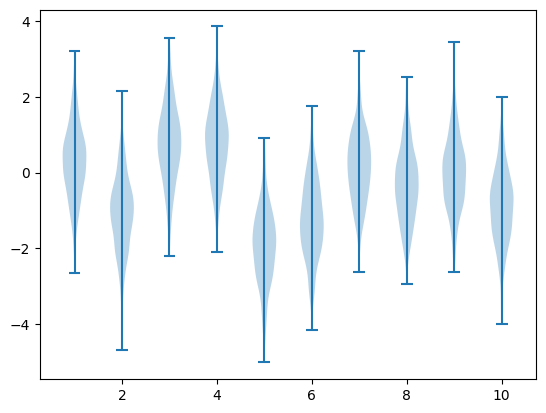

In [6]:
rewards = [[bandit(a) for r in range(0, 500)] for a in range(0,10)]

plt.violinplot(rewards);

## $\epsilon$-greedy action-value method

In [7]:
def bandit_algo_run(bandit, k, T, epsilon):
    """
    Run the epsilon-greedy algorithm on a particular k-armed bandit for T time steps.
    
    Args:
        bandit: bandit reward function; bandit(a) returns a real number for every possible action a.
        k: number of arms in the bandit
        T: number of timesteps played
        epsilon: probability with which an exploratory action is taken
    """

    n = np.zeros(k)              # number of times each action was taken (k,)
    actions = []                 # sequence of actions taken (T,)
    rewards = []                 # sequence of rewards received (T,)
    q_estimates = np.zeros(k)    # values estimates for each action at every step (k,)
    
    for t in range(0,T):
        # Determine greedy action, randomly breaking ties randomly
        greedy_actions = np.flatnonzero(q_estimates == q_estimates.max())
        greedy_action = np.random.choice(greedy_actions)
        
        # Determine exploratory action randomly
        exploratory_action = np.random.choice(range(0,10))
        exploratory_action
        
        # Choose eploratory action with epsilon probability, and the greedy actio otherwise
        a = np.random.choice([greedy_action, exploratory_action], p=[1-epsilon, epsilon])
        actions.append(a)
        
        # Determine reward for the chosen action
        r = bandit(a)
        rewards.append(r)
        
        # Update value estimates
        n[a] += 1
        q_estimates[a] += (r - q_estimates[a])/n[a]
    
    return rewards, actions

In [8]:
R = 100
k = 10
T = 1000
epsilon = 0.1

optimal_action_counts = np.zeros(T)

for r in range(0,R):
    bandit = Bandit(k)
    bandit_reward = bandit.reward
    bandit_best_action = bandit._best_action

    rewards, actions = bandit_algo_run(bandit_reward, k, T, epsilon)

    optimal_action = (actions == bandit_best_action)
    
    optimal_action_counts += optimal_action

optimal_action_percentage = optimal_action_counts*100/R
optimal_action_percentage

array([ 6.,  6., 13., 14., 15., 15., 21., 22., 21., 19., 26., 26., 30.,
       28., 31., 29., 31., 31., 31., 35., 36., 37., 34., 36., 36., 33.,
       37., 37., 33., 33., 33., 37., 40., 39., 40., 41., 42., 40., 43.,
       39., 42., 46., 43., 43., 37., 46., 45., 44., 41., 47., 44., 43.,
       43., 44., 50., 46., 47., 46., 47., 48., 47., 44., 48., 45., 49.,
       48., 45., 44., 43., 47., 50., 47., 47., 48., 47., 47., 49., 47.,
       46., 48., 50., 52., 54., 51., 48., 49., 48., 48., 49., 48., 48.,
       47., 45., 56., 47., 47., 50., 48., 51., 47., 53., 50., 53., 50.,
       53., 53., 50., 54., 48., 51., 59., 51., 50., 52., 57., 53., 54.,
       52., 51., 55., 56., 53., 54., 52., 55., 55., 55., 57., 59., 60.,
       59., 56., 57., 63., 62., 55., 57., 60., 62., 60., 58., 61., 62.,
       62., 59., 59., 63., 54., 60., 56., 57., 59., 54., 55., 61., 58.,
       59., 53., 60., 54., 57., 59., 62., 55., 55., 56., 55., 58., 62.,
       59., 60., 57., 58., 57., 61., 62., 58., 58., 62., 61., 60

In [9]:
def simulate(k, T, epsilon, R):
    """
    Run R runs of the epsilon-greedy algorithm on R different k-armed bandits for T time steps, and average the rewards from all runs for each time step.

    Args:
        k: number of arms in the bandit
        T: number of timesteps played
        epsilon: probability with which an exploratory action is taken
        R: number of runs
    """

    average_rewards = np.zeros(T)
    number_optimal_actions = np.zeros(T)
    
    for r in range(0,R):
        bandit = Bandit(k)
        bandit_best_action = bandit._best_action
        
        rewards, actions = bandit_algo_run(bandit.reward, k, T, epsilon)
        
        average_rewards = average_rewards + 1/(r+1)*(rewards - average_rewards)
        number_optimal_actions += (actions == bandit_best_action)

    percent_optimal_actions = number_optimal_actions*100/R

    return average_rewards, percent_optimal_actions

In [17]:
%%time

# Run 3000 runs for three different values of epsilon

k = 10                         # number of arms in the bandit
T = 3000                       # number of timesteps played
epsilons = [0.0, 0.01, 0.1]
R = 5000                       # number of runs to play in the simulation

average_rewards = np.empty((len(epsilons), T))
percent_optimal_actions = np.empty((len(epsilons), T))

for i, epsilon in enumerate(epsilons):
    average_rewards[i], percent_optimal_actions[i] = simulate(k, T, epsilon, R)

print("Average reward: ", np.mean(average_rewards, axis=1))

Average reward:  [1.02679595 1.33099234 1.34358088]
CPU times: user 15min 15s, sys: 3.21 s, total: 15min 18s
Wall time: 15min 14s


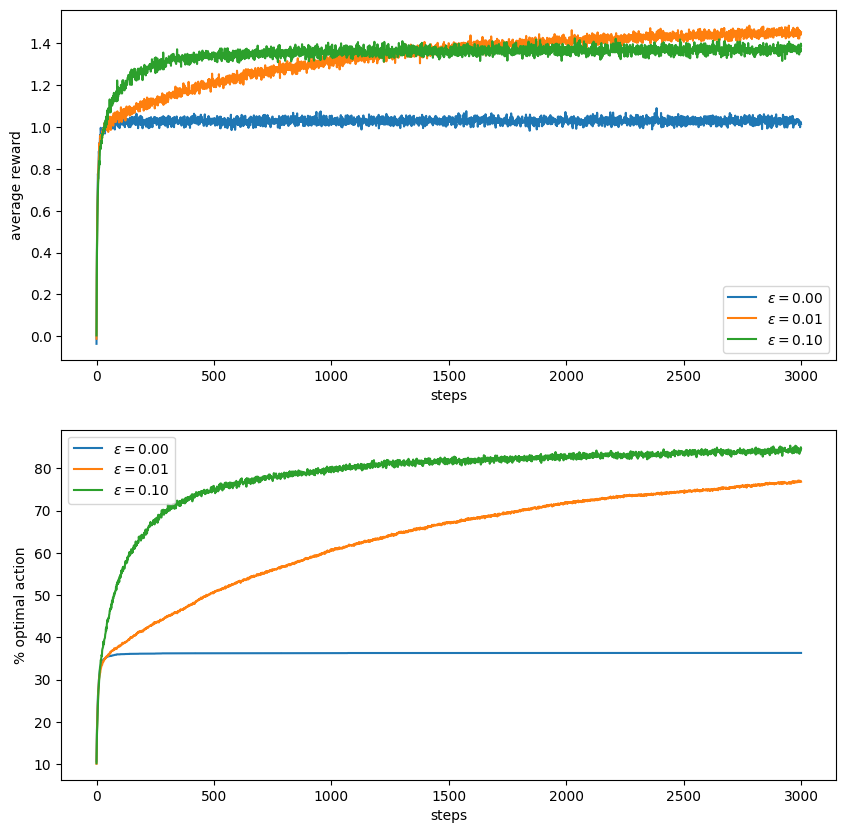

In [18]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
for i, epsilon in enumerate(epsilons):
    plt.plot(average_rewards[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()

plt.subplot(2, 1, 2)
for i, epsilon in enumerate(epsilons):
    plt.plot(percent_optimal_actions[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('% optimal action')
plt.legend()

plt.savefig('../images/figure_2_2.png')